# Project
# Comparing models for predicting house prices (Kaggle)

## Loading libraries

In [196]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

import warnings
warnings.filterwarnings('ignore', category = FutureWarning)
warnings.filterwarnings('ignore', category = UserWarning)

## Metric definition and custom scorer

In [197]:
def rmsle_score(y_true, y_pred):
    '''The function calculates the root mean squared logarithmic error (RMSLE) metric.'''
    y_pred[y_pred < 0] = 0 
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

rmsle_scorer = make_scorer(rmsle_score, greater_is_better = False)

## Loading data

In [198]:
train_data = pd.read_csv("home_data\\train.csv")
test_data = pd.read_csv("home_data\\test.csv")
sample_sub = pd.read_csv("home_data\\sample_submission.csv")

In [199]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

## EDA

In [200]:
print ('Training data head:\n', train_data.head(5))
print ('Test set head:\n', test_data.head(5))

Training data head:
    Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities LotConfig LandSlope Neighborhood Condition1  \
0         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
1         Lvl    AllPub       FR2       Gtl      Veenker      Feedr   
2         Lvl    AllPub    Inside       Gtl      CollgCr       Norm   
3         Lvl    AllPub    Corner       Gtl      Crawfor       Norm   
4         Lvl    AllPub       FR2       Gtl      NoRidge       Norm   

  Condition2 BldgType HouseStyle  OverallQual  OverallCond  YearBuilt  \
0       Norm     1Fam     2Story  

In [201]:
print ('Training data descriptive statistics:\n', train_data.describe(include = 'all'))
print ('Test data descriptive statistics:\n', test_data.describe(include = 'all'))

Training data descriptive statistics:
                  Id   MSSubClass MSZoning  LotFrontage        LotArea Street  \
count   1460.000000  1460.000000     1460  1201.000000    1460.000000   1460   
unique          NaN          NaN        5          NaN            NaN      2   
top             NaN          NaN       RL          NaN            NaN   Pave   
freq            NaN          NaN     1151          NaN            NaN   1454   
mean     730.500000    56.897260      NaN    70.049958   10516.828082    NaN   
std      421.610009    42.300571      NaN    24.284752    9981.264932    NaN   
min        1.000000    20.000000      NaN    21.000000    1300.000000    NaN   
25%      365.750000    20.000000      NaN    59.000000    7553.500000    NaN   
50%      730.500000    50.000000      NaN    69.000000    9478.500000    NaN   
75%     1095.250000    70.000000      NaN    80.000000   11601.500000    NaN   
max     1460.000000   190.000000      NaN   313.000000  215245.000000    NaN   



## Data splitting

In [202]:
y = train_data['SalePrice']
y_log = np.log1p(y)

train_data = train_data.drop('SalePrice', axis = 1)

X = pd.concat([train_data, test_data], ignore_index = True)

N_rows_x_train = train_data.shape[0]

## Missing data imputation

In [203]:
print (X.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             2919 non-null   int64  
 1   MSSubClass     2919 non-null   int64  
 2   MSZoning       2915 non-null   object 
 3   LotFrontage    2433 non-null   float64
 4   LotArea        2919 non-null   int64  
 5   Street         2919 non-null   object 
 6   Alley          198 non-null    object 
 7   LotShape       2919 non-null   object 
 8   LandContour    2919 non-null   object 
 9   Utilities      2917 non-null   object 
 10  LotConfig      2919 non-null   object 
 11  LandSlope      2919 non-null   object 
 12  Neighborhood   2919 non-null   object 
 13  Condition1     2919 non-null   object 
 14  Condition2     2919 non-null   object 
 15  BldgType       2919 non-null   object 
 16  HouseStyle     2919 non-null   object 
 17  OverallQual    2919 non-null   int64  
 18  OverallC

In [204]:
print (X.isnull().sum())

Id                  0
MSSubClass          0
MSZoning            4
LotFrontage       486
LotArea             0
Street              0
Alley            2721
LotShape            0
LandContour         0
Utilities           2
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         1
Exterior2nd         1
MasVnrType       1766
MasVnrArea         23
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           81
BsmtCond           82
BsmtExposure       82
BsmtFinType1       79
BsmtFinSF1          1
BsmtFinType2       80
BsmtFinSF2          1
BsmtUnfSF           1
TotalBsmtSF         1
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

In [205]:
X['LotFrontage'] = X.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))

for col in ['GarageYrBlt', 'MasVnrArea', 'GarageArea', 'GarageCars', 'TotalBsmtSF', 'BsmtUnfSF', 'BsmtFullBath', 'BsmtHalfBath']:
    X[col] = X[col].fillna(0)

mask = (X['TotalBsmtSF'] ==  0)
fill_cols_bsmt_1 = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']
for i_col in fill_cols_bsmt_1:
    X.loc[mask | X[i_col].isna(), i_col] = 'NoBsmt'
fill_cols_bsmt_2 = ['BsmtExposure', 'BsmtFinType2', 'BsmtFinSF1', 'BsmtFinSF2']
for j_col in fill_cols_bsmt_2:
    X[j_col] = X[j_col].fillna('Unf')

mask = (X['GarageArea'] ==  0)
fill_cols_garage = ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']
for col in fill_cols_garage:
    X.loc[mask | X[col].isna(), col] = 'NoGarage'

mask = (X['PoolArea'] ==  0)
X.loc[mask & X['PoolQC'].isna(), 'PoolQC'] = 'NoPool'
X.loc[X['PoolQC'].isna(), 'PoolQC'] = 'Unf'

fill_values = {
    'Alley': 'NoAlley',
    'MasVnrType': 'NoMasVnr',
    'FireplaceQu': 'NoFireplace',
    'Fence': 'NoFence',
    'MSZoning': 'Unf',
    'Utilities': 'NoUtilities',
    'Exterior1st': 'NoExterior',
    'Exterior2nd': 'NoExterior',
    'SaleType': 'Unf',
    'Electrical': 'Unf',
    'KitchenQual': 'Unf',
    'Functional': 'Unf'
}
for col, val in fill_values.items():
    X.loc[X[col].isna(), col] = val

X = X.drop('MiscFeature', axis = 1)

In [206]:
print (X.isnull().sum())

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr

## Distribution of the target variable

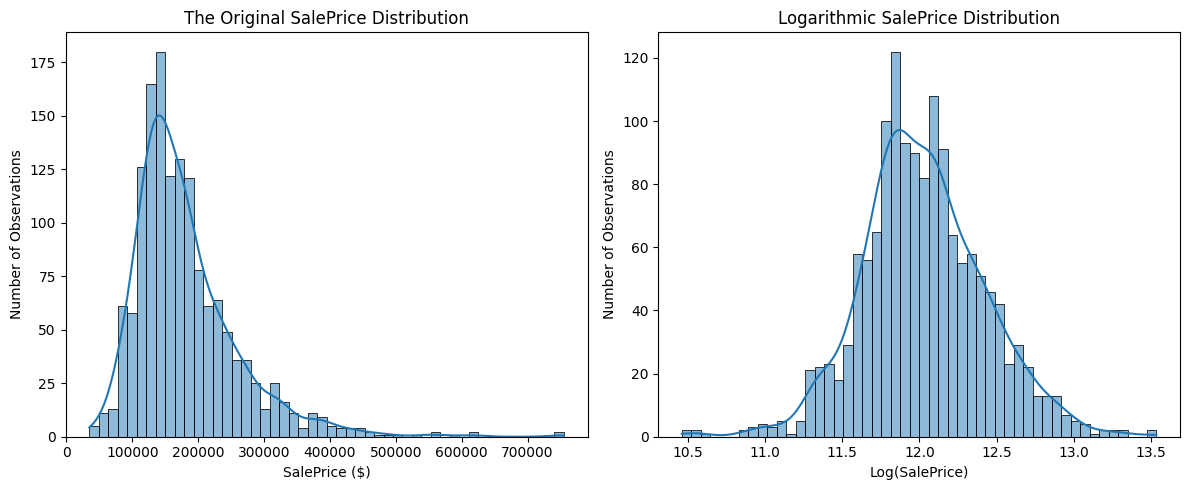

In [207]:
plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
sns.histplot(y, kde = True, bins = 50)
plt.title('The Original SalePrice Distribution')
plt.ylabel('Number of Observations')
plt.xlabel('SalePrice ($)')

plt.subplot(1, 2, 2)
sns.histplot(y_log, kde = True, bins = 50)
plt.title('Logarithmic SalePrice Distribution')
plt.ylabel('Number of Observations')
plt.xlabel('Log(SalePrice)')

plt.tight_layout()
plt.savefig('images/sale_price_comparison.png') 
plt.show()

## Data splitting

In [208]:
X['MSSubClass'] = X['MSSubClass'].astype(str)

X_train = X.iloc[:N_rows_x_train, :].drop('Id', axis = 1)
X_test = X.iloc[N_rows_x_train:, :].drop('Id', axis = 1)

X_train_train, X_train_test, y_train_log, y_test_log = train_test_split(X_train, y_log, test_size = 0.25, random_state = 42)

y_test = np.expm1(y_test_log)

In [209]:
X_test.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
Alley            0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       0
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual 

## Model evaluation function

In [210]:
def evaluate_model(model, X_train_test, y_test, y_test_log, model_name):
    """The function evaluates the trained model and returns all metrics."""
    
    y_pred_log = model.predict(X_train_test)
    
    y_pred = np.expm1(y_pred_log)
    y_pred[y_pred < 0] = 0

    rmsle = rmsle_score(y_test, y_pred) 

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"Results {model_name:<15} | RMSLE: {rmsle:.5f} | RMSE: {rmse:.0f} $ | R2: {r2:.4f}")
    return {'RMSLE': rmsle, 'RMSE ($)': rmse, 'R2': r2, 'MAE ($)': mae, 'y_pred': y_pred}

## Feature engineering and preprocessing setup

In [211]:
numerical_features = X_train.select_dtypes(include = ['int64', 'float64']).columns.tolist()

categorical_features = X_train.select_dtypes(include = ['object']).columns.tolist()

for col in categorical_features:
    X_train_train[col] = X_train_train[col].astype(str)
    X_train_test[col] = X_train_test[col].astype(str)
    X_test.loc[:, col] = X_test[col].astype(str)

if 'MSSubClass' not in categorical_features:
    categorical_features.append('MSSubClass')

In [212]:
full_preprocessor = ColumnTransformer(
    transformers = [('scaler', StandardScaler(), numerical_features),
                  ('onehot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)],
    remainder = 'drop')

In [213]:
categorical_encoder = ColumnTransformer(
    transformers = [('onehot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)],
    remainder = 'passthrough')

## Manual feature selection for collinearity

GarageArea    GarageCars      0.882475
TotRmsAbvGrd  GrLivArea       0.825489
1stFlrSF      TotalBsmtSF     0.819530
GrLivArea     2ndFlrSF        0.687501
TotRmsAbvGrd  BedroomAbvGr    0.676620
FullBath      GrLivArea       0.630012
TotRmsAbvGrd  2ndFlrSF        0.616423
HalfBath      2ndFlrSF        0.609707
GarageCars    OverallQual     0.600671
              GarageYrBlt     0.598005
dtype: float64
Dropping columns: 
 ['TotalBsmtSF', 'GrLivArea', 'GarageCars']

Number of observations and features after removing highly correlated features:
 (2919, 75)


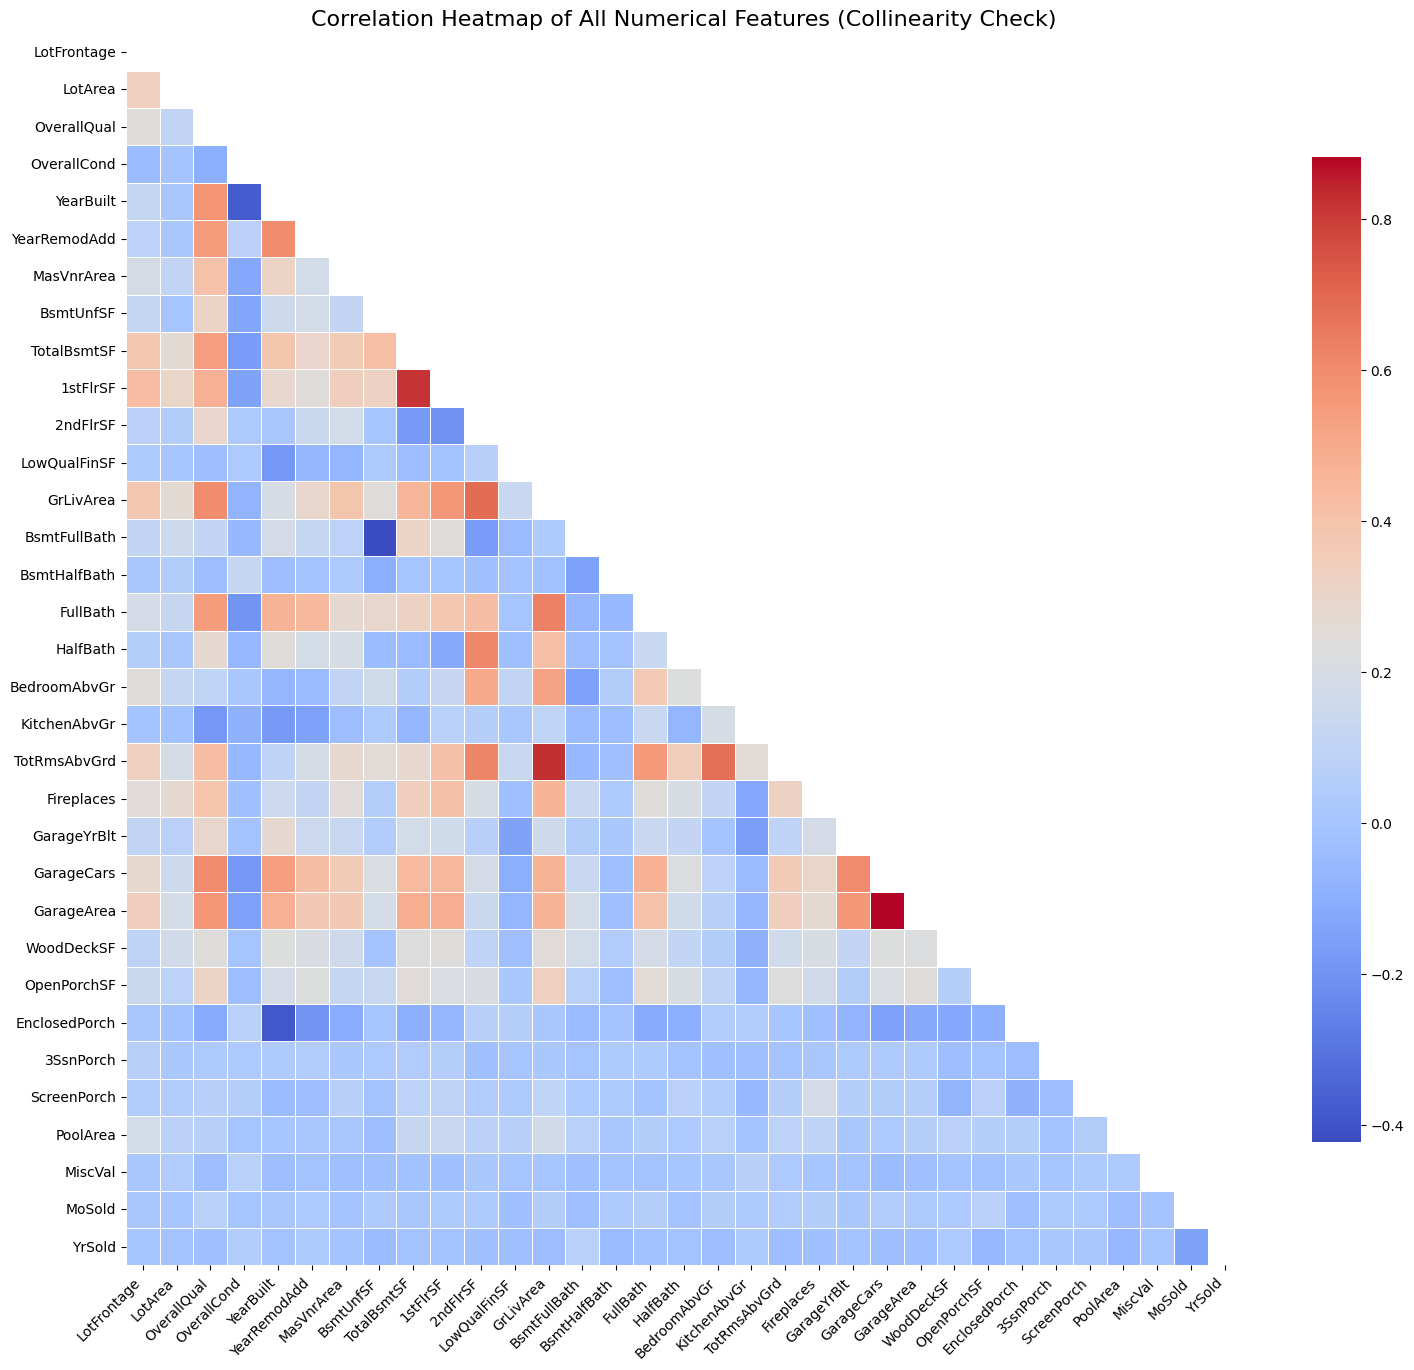

In [214]:
corr_matrix = X_train[numerical_features].corr()
triangle = corr_matrix.abs().where(np.tril(np.ones(corr_matrix.shape), k = -1).astype(bool))
print(triangle.stack().sort_values(ascending = False)[:10])
to_drop = [column for column in triangle.columns if any(triangle[column] > 0.8)]
print("Dropping columns: \n", to_drop)
X_no_collinearity = X.drop(to_drop, axis = 1).drop('Id', axis = 1)
print("\nNumber of observations and features after removing highly correlated features:\n", X_no_collinearity.shape)

n_features = corr_matrix.shape[0]
mask = np.triu(corr_matrix)
plt.figure(figsize = (18, 16))
sns.heatmap(
    corr_matrix, 
    mask = mask,
    annot = False,
    cmap = 'coolwarm', 
    fmt = ".2f", 
    linewidths = 0.5,
    cbar_kws = {'shrink': 0.8})
plt.title('Correlation Heatmap of All Numerical Features (Collinearity Check)', fontsize = 16)
plt.xticks(rotation = 45, ha = 'right')
plt.yticks(rotation = 0)
plt.savefig('images/full_collinearity_heatmap.png', bbox_inches = 'tight') 
plt.show()

In [215]:
X_train_no_collinearity = X_no_collinearity.iloc[:N_rows_x_train, :]
X_test_no_collinearity = X_no_collinearity.iloc[N_rows_x_train:, :]

X_train_train_NC, X_train_test_NC, y_train_log_NC, y_test_log_NC = train_test_split(X_train_no_collinearity, y_log, test_size = 0.25, random_state = 42)

numerical_features_NC = X_train_no_collinearity.select_dtypes(include = ['int64', 'float64']).columns.tolist()
categorical_features_NC = X_train_no_collinearity.select_dtypes(include = ['object']).columns.tolist()

full_preprocessor_NC = ColumnTransformer(
    transformers = [('scaler', StandardScaler(), numerical_features_NC),
                  ('onehot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features_NC)],
    remainder = 'drop')

## PCA preprocessing

In [216]:
pca_data_preprocessor = ColumnTransformer(
    transformers = [('scaler', StandardScaler(), numerical_features),
                  ('onehot', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), categorical_features)],
    remainder = 'drop')

## Pipeline definition

In [217]:
def create_PCA_pipeline(regressor_model):
    '''The function creates a scikit-learn pipeline that chains the data preprocessor,
    Principal Component Analysis (PCA) for dimensionality reduction, and the specified regressor.'''
    return Pipeline(steps = [
        ('preprocessor', pca_data_preprocessor),
        ('pca', PCA(random_state = 42)),
        ('regressor', regressor_model)])

def create_poly_pipeline(regressor_model):
    '''The function creates a scikit-learn pipeline for polynomial regression by chaining a preprocessor, 
    polynomial feature generation, and the specified regressor model.'''
    return Pipeline(steps = [('preprocessor', full_preprocessor), 
                           ('poly', PolynomialFeatures(include_bias = False)), 
                           ('regressor', regressor_model)])

def create_poly_PCA_pipeline(regressor_model):
    '''The function creates a pipeline for polynomial regression that applies the data preprocessor, PCA,
    Polynomial Features (degree = 2), and the specified regressor model.'''
    return Pipeline(steps = [
        ('preprocessor', pca_data_preprocessor), 
        ('pca', PCA(random_state = 42)), 
        ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
        ('regressor', regressor_model)])

def create_poly_NC_pipeline(regressor_model):
    '''The function creates a pipeline for polynomial regression that uses the No-Collinearity (NC) preprocessor,
    followed by Polynomial Features (degree = 2) and the specified regressor model.'''
    return Pipeline(steps = [
        ('preprocessor', full_preprocessor_NC), 
        ('poly', PolynomialFeatures(degree = 2, include_bias = False)),
        ('regressor', regressor_model)])

def create_standard_pipeline(regressor_model):
    '''The function creates a standard pipeline using the full_preprocessor (scaling, encoding) and the specified regressor model.'''
    return Pipeline(steps = [
        ('preprocessor', full_preprocessor), 
        ('regressor', regressor_model)])

def create_NC_pipeline(regressor_model):
    '''The function creates a pipeline using the No-Collinearity (NC) preprocessor and the specified regressor model.'''
    return Pipeline(steps = [
        ('preprocessor', full_preprocessor_NC), 
        ('regressor', regressor_model)])

def create_tree_pipeline(regressor_model):
    '''The function creates a pipeline optimized for tree-based models, using only the categorical_encoder preprocessor and 
    the specified regressor model.'''
    return Pipeline(steps = [
        ('preprocessor', categorical_encoder), 
        ('regressor', regressor_model)])

In [218]:
results = {}
final_pipelines = {}
kf = KFold(5, shuffle = True, random_state = 42)

## Linear regression (OLS): manual collinearity removal

In [219]:
pipeline_OLS_NC = create_NC_pipeline(LinearRegression(n_jobs = -1))

pipeline_OLS_NC.fit(X_train_train_NC, y_train_log_NC)
best_OLS_NC = pipeline_OLS_NC

results['OLS_NC'] = evaluate_model(best_OLS_NC, X_train_test_NC, y_test, y_test_log, 'OLS_NC')
final_pipelines['OLS_NC'] = best_OLS_NC

Results OLS_NC          | RMSLE: 0.20247 | RMSE: 35505 $ | R2: 0.8200


## Linear regression (OLS) with PCA

In [220]:
pipeline_OLS_PCA = create_PCA_pipeline(LinearRegression(n_jobs = -1))

param_grid_OLS_PCA = {'pca__n_components': [0.9, 0.95, 0.99]}

grid_search_OLS_PCA = GridSearchCV(
    pipeline_OLS_PCA, 
    param_grid_OLS_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_OLS_PCA.fit(X_train_train, y_train_log)
best_OLS_PCA = grid_search_OLS_PCA.best_estimator_

results['OLS_PCA'] = evaluate_model(best_OLS_PCA, X_train_test, y_test, y_test_log, 'OLS_PCA')
final_pipelines['OLS_PCA'] = best_OLS_PCA

best_params_OLS_PCA = grid_search_OLS_PCA.best_params_
print(f"Optimal hyperparameters for OLS (PCA): {best_params_OLS_PCA}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Results OLS_PCA         | RMSLE: 0.13691 | RMSE: 26021 $ | R2: 0.9033
Optimal hyperparameters for OLS (PCA): {'pca__n_components': 0.95}


## Ridge regression (L2 regularization): full feature set (no collinearity pre-processing)

In [221]:
pipeline_ridge = create_standard_pipeline(Ridge(random_state = 42))

param_grid_ridge = {'regressor__alpha': [10.0, 15.0, 20.0, 25.0, 30.0]}

grid_search_ridge = GridSearchCV(
    pipeline_ridge, 
    param_grid_ridge, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_ridge.fit(X_train_train, y_train_log)
best_ridge = grid_search_ridge.best_estimator_

results['Ridge'] = evaluate_model(best_ridge, X_train_test, y_test, y_test_log, 'Ridge')
final_pipelines['Ridge'] = best_ridge

best_params_ridge = grid_search_ridge.best_params_
print(f"Optimal hyperparameters for Ridge: {best_params_ridge}")

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Results Ridge           | RMSLE: 0.13358 | RMSE: 25086 $ | R2: 0.9102
Optimal hyperparameters for Ridge: {'regressor__alpha': 20.0}


## Lasso regression (L1 regularization): full feature set (no collinearity pre-processing)

In [222]:
pipeline_lasso = create_standard_pipeline(Lasso(random_state = 42, max_iter = 2000))

param_grid_lasso = {'regressor__alpha': [0.0005, 0.001, 0.005, 0.01, 0.05, 0.1]}

grid_search_lasso = GridSearchCV(
    pipeline_lasso, 
    param_grid_lasso, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_lasso.fit(X_train_train, y_train_log)
best_lasso = grid_search_lasso.best_estimator_

results['Lasso'] = evaluate_model(best_lasso, X_train_test, y_test, y_test_log, 'Lasso')
final_pipelines['Lasso'] = best_lasso

best_params_lasso = grid_search_lasso.best_params_
print(f"Optimal hyperparameters for Lasso: {best_params_lasso}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Results Lasso           | RMSLE: 0.12999 | RMSE: 23925 $ | R2: 0.9183
Optimal hyperparameters for Lasso: {'regressor__alpha': 0.001}


## Elastic net regression: full feature set (no collinearity pre-processing)

In [223]:
pipeline_elastic_net = create_standard_pipeline(ElasticNet(random_state = 42, max_iter = 2000))

param_grid_elastic_net = {
    'regressor__alpha': [0.0005, 0.001, 0.01, 0.1], 
    'regressor__l1_ratio': [0.1, 0.5, 0.7, 0.9, 0.95, 1.0]}

grid_search_elastic_net = GridSearchCV(
    pipeline_elastic_net, 
    param_grid_elastic_net, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_elastic_net.fit(X_train_train, y_train_log)
best_elastic_net = grid_search_elastic_net.best_estimator_

results['ElasticNet'] = evaluate_model(best_elastic_net, X_train_test, y_test, y_test_log, 'ElasticNet')
final_pipelines['ElasticNet'] = best_elastic_net

best_params_elastic_net = grid_search_elastic_net.best_params_
print(f"Optimal hyperparameters for Elastic Net: {best_params_elastic_net}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Results ElasticNet      | RMSLE: 0.12999 | RMSE: 23925 $ | R2: 0.9183
Optimal hyperparameters for Elastic Net: {'regressor__alpha': 0.001, 'regressor__l1_ratio': 1.0}


## Polynomial regression: manual collinearity removal

In [224]:
pipeline_poly_OLS_NC = create_poly_NC_pipeline(regressor_model = LinearRegression(n_jobs = -1))

pipeline_poly_OLS_NC.fit(X_train_train_NC, y_train_log_NC)
best_poly_OLS_NC = pipeline_poly_OLS_NC

results['PolyOLS_NC'] = evaluate_model(best_poly_OLS_NC, X_train_test_NC, y_test, y_test_log, 'PolyOLS_NC')
final_pipelines['PolyOLS_NC'] = best_poly_OLS_NC

Results PolyOLS_NC      | RMSLE: 0.20004 | RMSE: 94041 $ | R2: -0.2624


## Polynomial regression with PCA

In [225]:
pipeline_poly_OLS_PCA = create_poly_PCA_pipeline(LinearRegression(n_jobs = -1))

param_grid_poly_OLS_PCA = {'pca__n_components': [0.9, 0.95, 0.99]}

grid_search_poly_OLS_PCA = GridSearchCV(
    pipeline_poly_OLS_PCA, 
    param_grid_poly_OLS_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_poly_OLS_PCA.fit(X_train_train, y_train_log)
best_poly_OLS_PCA =  grid_search_poly_OLS_PCA.best_estimator_

results['Poly_OLS_PCA'] = evaluate_model(best_poly_OLS_PCA, X_train_test, y_test, y_test_log, 'Poly_OLS_PCA')
final_pipelines['Poly_OLS_PCA'] = best_poly_OLS_PCA

best_params_poly_OLS_PCA = grid_search_poly_OLS_PCA.best_params_
print(f"Optimal hyperparameters for Poly + OLS (PCA): {best_params_poly_OLS_PCA}")

Fitting 5 folds for each of 3 candidates, totalling 15 fits
Results Poly_OLS_PCA    | RMSLE: 0.17169 | RMSE: 34009 $ | R2: 0.8349
Optimal hyperparameters for Poly + OLS (PCA): {'pca__n_components': 0.99}


## Polynomial regression + L2 regularization with PCA

In [226]:
pipeline_poly_ridge_PCA = create_poly_PCA_pipeline(Ridge(random_state = 42))

param_grid_poly_ridge_PCA = {
    'pca__n_components': [0.65, 0.70, 0.75], 
    'regressor__alpha': [100.0, 150.0, 175.0, 200.0]}

grid_search_poly_ridge_PCA = GridSearchCV(
    pipeline_poly_ridge_PCA, 
    param_grid_poly_ridge_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_poly_ridge_PCA.fit(X_train_train, y_train_log)
best_poly_ridge_PCA = grid_search_poly_ridge_PCA.best_estimator_

results['PolyRidge_PCA'] = evaluate_model(best_poly_ridge_PCA, X_train_test, y_test, y_test_log, 'PolyRidge_PCA')
final_pipelines['PolyRidge_PCA'] = best_poly_ridge_PCA

best_params_poly_ridge_PCA = grid_search_poly_ridge_PCA.best_params_
print(f"Optimal hyperparameters for Poly + Ridge (PCA): {best_params_poly_ridge_PCA}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Results PolyRidge_PCA   | RMSLE: 0.14325 | RMSE: 29941 $ | R2: 0.8720
Optimal hyperparameters for Poly + Ridge (PCA): {'pca__n_components': 0.7, 'regressor__alpha': 175.0}


## Polynomial regression + (L1 regularization): full feature set (no collinearity pre-processing)

In [227]:
pipeline_poly_lasso_PCA = create_poly_PCA_pipeline(Lasso(random_state = 42, max_iter = 5000))

param_grid_poly_lasso_PCA = {
    'pca__n_components': [100, 125, 175, 200], 
    'regressor__alpha': [0.001, 0.005, 0.01, 0.05]}

grid_search_poly_lasso_PCA = GridSearchCV(
    pipeline_poly_lasso_PCA, 
    param_grid_poly_lasso_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1, n_jobs = -1)

grid_search_poly_lasso_PCA.fit(X_train_train, y_train_log)
best_poly_lasso_PCA = grid_search_poly_lasso_PCA.best_estimator_

results['PolyLasso_PCA'] = evaluate_model(best_poly_lasso_PCA, X_train_test, y_test, y_test_log, 'PolyLasso_PCA')
final_pipelines['PolyLasso_PCA'] = best_poly_lasso_PCA

best_params_poly_lasso_PCA = grid_search_poly_lasso_PCA.best_params_
print(f"Optimal hyperparameters for Poly + Lasso (PCA): {best_params_poly_lasso_PCA}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Results PolyLasso_PCA   | RMSLE: 0.14391 | RMSE: 29308 $ | R2: 0.8774
Optimal hyperparameters for Poly + Lasso (PCA): {'pca__n_components': 175, 'regressor__alpha': 0.005}


## Polynomial regression + elastic net: full feature set (no collinearity pre-processing)

In [228]:
pipeline_poly_elastic_net_PCA = create_poly_PCA_pipeline(ElasticNet(random_state = 42, max_iter = 5000))

param_grid_poly_elastic_net_PCA = {
    'pca__n_components': [150, 175, 200], 
    'regressor__alpha': [0.005, 0.01, 0.015],
    'regressor__l1_ratio': [0.4, 0.5, 0.6]}

grid_search_poly_elastic_net_PCA = GridSearchCV(
    pipeline_poly_elastic_net_PCA, 
    param_grid_poly_elastic_net_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_poly_elastic_net_PCA.fit(X_train_train, y_train_log)
best_poly_elastic_net_PCA = grid_search_poly_elastic_net_PCA.best_estimator_

results['PolyElasticNet_PCA'] = evaluate_model(best_poly_elastic_net_PCA, X_train_test, y_test, y_test_log, 'PolyElasticNet_PCA')
final_pipelines['PolyElasticNet_PCA'] = best_poly_elastic_net_PCA

best_params_poly_elastic_net_PCA = grid_search_poly_elastic_net_PCA.best_params_
print(f"Optimal hyperparameters for Poly + ElasticNet (PCA): {best_params_poly_elastic_net_PCA}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Results PolyElasticNet_PCA | RMSLE: 0.14335 | RMSE: 29321 $ | R2: 0.8773
Optimal hyperparameters for Poly + ElasticNet (PCA): {'pca__n_components': 150, 'regressor__alpha': 0.01, 'regressor__l1_ratio': 0.5}


## K-nearest neighbors regression (K-NN regression): full feature set (no collinearity pre-processing)

In [229]:
pipeline_KNN = create_standard_pipeline(KNeighborsRegressor(n_jobs = -1))

param_grid_KNN = {
    'regressor__n_neighbors': [3, 5, 7, 9], 
    'regressor__weights': ['uniform', 'distance'], 
    'regressor__p': [1, 2]}

grid_search_KNN = GridSearchCV(
    pipeline_KNN, 
    param_grid_KNN, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_KNN.fit(X_train_train, y_train_log)
best_KNN = grid_search_KNN.best_estimator_

results['KNN'] = evaluate_model(best_KNN, X_train_test, y_test, y_test_log, 'KNN')
final_pipelines['KNN'] = best_KNN

best_params_KNN = grid_search_KNN.best_params_
print(f"Optimal hyperparameters for K-NN: {best_params_KNN}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Results KNN             | RMSLE: 0.17967 | RMSE: 35325 $ | R2: 0.8219
Optimal hyperparameters for K-NN: {'regressor__n_neighbors': 5, 'regressor__p': 1, 'regressor__weights': 'distance'}


## K-nearest neighbors regression (K-NN regression): manual collinearity removal

In [230]:
pipeline_KNN_NC = create_NC_pipeline(KNeighborsRegressor(n_jobs = -1))

param_grid_KNN_NC = {
    'regressor__n_neighbors': [3, 5, 7], 
    'regressor__weights': ['uniform', 'distance'], 
    'regressor__p': [1, 2]}

grid_search_KNN_NC = GridSearchCV(
    pipeline_KNN_NC, 
    param_grid_KNN_NC, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_KNN_NC.fit(X_train_train_NC, y_train_log_NC)
best_KNN_NC = grid_search_KNN_NC.best_estimator_

results['K-NN_NC'] = evaluate_model(best_KNN_NC, X_train_test_NC, y_test, y_test_log, 'K-NN_NC')
final_pipelines['K-NN_NC'] = best_KNN_NC

best_params_KNN_NC = grid_search_KNN_NC.best_params_
print(f"Optimal hyperparameters for K-NN (NC): {best_params_KNN_NC}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Results K-NN_NC         | RMSLE: 0.17860 | RMSE: 36335 $ | R2: 0.8115
Optimal hyperparameters for K-NN (NC): {'regressor__n_neighbors': 5, 'regressor__p': 1, 'regressor__weights': 'distance'}


## K-nearest neighbors regression (K-NN regression) with PCA

In [231]:
pipeline_KNN_PCA = create_PCA_pipeline(KNeighborsRegressor(n_jobs = -1))

param_grid_KNN_PCA = {
    'pca__n_components': [0.85, 0.9, 0.95], 
    'regressor__n_neighbors': [10, 15, 20], 
    'regressor__weights': ['uniform', 'distance']}

grid_search_KNN_PCA = GridSearchCV(
    pipeline_KNN_PCA, 
    param_grid_KNN_PCA, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_KNN_PCA.fit(X_train_train, y_train_log)
best_KNN_PCA = grid_search_KNN_PCA.best_estimator_

results['K-NN_PCA'] = evaluate_model(best_KNN_PCA, X_train_test, y_test, y_test_log, 'K-NN_PCA')
final_pipelines['K-NN_PCA'] = best_KNN_PCA

best_params_KNN_PCA = grid_search_KNN_PCA.best_params_
print(f"Optimal hyperparameters for KNN (PCA): {best_params_KNN_PCA}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Results K-NN_PCA        | RMSLE: 0.17211 | RMSE: 37771 $ | R2: 0.7963
Optimal hyperparameters for KNN (PCA): {'pca__n_components': 0.9, 'regressor__n_neighbors': 15, 'regressor__weights': 'distance'}


## Support vector regression (SVR): full feature set (no collinearity pre-processing)

In [232]:
pipeline_SVR = create_standard_pipeline(SVR(kernel = 'rbf'))

param_grid_SVR = {
    'regressor__C': [0.1, 1, 2], 
    'regressor__gamma': ['scale', 0.01, 0.1], 
    'regressor__epsilon': [0.01, 0.1]}

grid_search_SVR = GridSearchCV(
    pipeline_SVR, 
    param_grid_SVR,
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_SVR.fit(X_train_train, y_train_log)
best_SVR = grid_search_SVR.best_estimator_

# Оценка
results['SVR'] = evaluate_model(best_SVR, X_train_test, y_test, y_test_log, 'SVR')
final_pipelines['SVR'] = best_SVR

best_params_SVR = grid_search_SVR.best_params_
print(f"Optimal hyperparameters for SVR: {best_params_SVR}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Results SVR             | RMSLE: 0.12877 | RMSE: 27882 $ | R2: 0.8890
Optimal hyperparameters for SVR: {'regressor__C': 1, 'regressor__epsilon': 0.01, 'regressor__gamma': 0.01}


## Support vector regression (SVR): manual collinearity removal

In [233]:
pipeline_SVR_NC = create_NC_pipeline(SVR(kernel = 'rbf'))

param_grid_SVR_NC = {
    'regressor__C': [0.1, 1, 2], 
    'regressor__gamma': ['scale', 0.01, 0.1], 
    'regressor__epsilon': [0.01, 0.1]}

grid_search_SVR_NC = GridSearchCV(
    pipeline_SVR_NC, 
    param_grid_SVR_NC,
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_SVR_NC.fit(X_train_train_NC, y_train_log_NC)
best_SVR_NC = grid_search_SVR_NC.best_estimator_

results['SVR_NC'] = evaluate_model(best_SVR_NC, X_train_test_NC, y_test, y_test_log, 'SVR_NC')
final_pipelines['SVR_NC'] = best_SVR_NC

best_params_SVR_NC = grid_search_SVR_NC.best_params_
print(f"Optimal hyperparameters for SVR (NC): {best_params_SVR_NC}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Results SVR_NC          | RMSLE: 0.13117 | RMSE: 27693 $ | R2: 0.8905
Optimal hyperparameters for SVR (NC): {'regressor__C': 1, 'regressor__epsilon': 0.01, 'regressor__gamma': 0.01}


## Support vector regression (SVR) with PCA

In [234]:
pipeline_SVR_PCA = create_PCA_pipeline(SVR(kernel='rbf'))

param_grid_SVR_PCA = {
    'pca__n_components': [0.9, 0.95, 0.99],
    'regressor__C': [0.1, 1, 2],
    'regressor__gamma': ['scale', 0.01, 0.05],
    'regressor__epsilon': [0.01, 0.05]}

grid_search_SVR_PCA = GridSearchCV(
    pipeline_SVR_PCA,
    param_grid_SVR_PCA,
    scoring = rmsle_scorer,
    cv = kf,
    verbose = 2,
    n_jobs = -1)

grid_search_SVR_PCA.fit(X_train_train, y_train_log)
best_SVR_PCA = grid_search_SVR_PCA.best_estimator_

results['SVR_PCA'] = evaluate_model(best_SVR_PCA, X_train_test, y_test, y_test_log, 'SVR_PCA')
final_pipelines['SVR_PCA'] = best_SVR_PCA 

best_params_SVR_PCA = grid_search_SVR_PCA.best_params_
print(f"Optimal hyperparameters for SVR (PCA): {best_params_SVR_PCA}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Results SVR_PCA         | RMSLE: 0.12861 | RMSE: 28088 $ | R2: 0.8874
Optimal hyperparameters for SVR (PCA): {'pca__n_components': 0.99, 'regressor__C': 1, 'regressor__epsilon': 0.01, 'regressor__gamma': 0.01}


## Decision tree

In [235]:
pipeline_decision_tree = create_tree_pipeline(RandomForestRegressor(random_state = 42, n_jobs = -1))

param_grid_decision_tree = {
    'regressor__max_depth': [12, 15, 18],
    'regressor__min_samples_leaf': [5, 8, 10],
    'regressor__min_samples_split': [10, 15, 18],
    'regressor__max_features': [0.85, 'sqrt']}

grid_search_decision_tree = GridSearchCV(
    pipeline_decision_tree, 
    param_grid_decision_tree, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

grid_search_decision_tree.fit(X_train_train, y_train_log)
best_decision_tree = grid_search_decision_tree.best_estimator_

results['DecisionTree'] = evaluate_model(best_decision_tree, X_train_test, y_test, y_test_log, 'DecisionTree')
final_pipelines['DecisionTree'] = best_decision_tree

best_params_decision_tree = grid_search_decision_tree.best_params_
print(f"Optimal hyperparameters for Decision Tree: {best_params_decision_tree}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Results DecisionTree    | RMSLE: 0.14551 | RMSE: 30218 $ | R2: 0.8697
Optimal hyperparameters for Decision Tree: {'regressor__max_depth': 15, 'regressor__max_features': 0.85, 'regressor__min_samples_leaf': 5, 'regressor__min_samples_split': 10}


## Random forest

In [236]:
pipeline_random_forest = create_tree_pipeline(RandomForestRegressor(random_state = 42, n_jobs = -1))

param_grid_random_forest = {
    'regressor__n_estimators': [150, 200, 250], 
    'regressor__max_depth': [15, 16],
    'regressor__max_features': [0.8, 'sqrt'],
    'regressor__min_samples_leaf': [1, 2],
    'regressor__min_samples_split': [2, 3]}

grid_search_random_forest = GridSearchCV(
    pipeline_random_forest, 
    param_grid_random_forest, 
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 0, 
    n_jobs = -1)

grid_search_random_forest.fit(X_train_train, y_train_log)
best_random_forest = grid_search_random_forest.best_estimator_

results['RandomForest'] = evaluate_model(best_random_forest, X_train_test, y_test, y_test_log, 'RandomForest')
final_pipelines['RandomForest'] = best_random_forest

best_params_random_forest = grid_search_random_forest.best_params_
print(f"Optimal Hyperparameters for Random Forest: {best_params_random_forest}")

Results RandomForest    | RMSLE: 0.13885 | RMSE: 27455 $ | R2: 0.8924
Optimal Hyperparameters for Random Forest: {'regressor__max_depth': 16, 'regressor__max_features': 0.8, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 3, 'regressor__n_estimators': 200}


## XGBoost

In [237]:
pipeline_XGB = create_tree_pipeline(XGBRegressor(random_state = 42, n_jobs = -1))

param_grid_XGB = {'regressor__n_estimators': [500, 1000], 
                  'regressor__learning_rate': [0.03, 0.05],
                  'regressor__max_depth': [3, 4], 
                  'regressor__min_child_weight': [15, 20], 
                  'regressor__gamma': [0, 0.05, 0.1], 
                  'regressor__subsample': [0.7, 0.8],
                  'regressor__colsample_bytree': [0.6, 0.7],
                  'regressor__reg_alpha': [0, 0.05],
                  'regressor__reg_lambda': [0.5, 1]}

random_search_XGB = RandomizedSearchCV(
    pipeline_XGB, 
    param_grid_XGB,
    n_iter = 200,
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 0, 
    n_jobs = -1)

random_search_XGB.fit(X_train_train, y_train_log)
best_XGB = random_search_XGB.best_estimator_

results['XGBoost'] = evaluate_model(best_XGB, X_train_test, y_test, y_test_log, 'XGBoost')
final_pipelines['XGBoost'] = best_XGB

best_params_XGB = random_search_XGB.best_params_
print(f"Optimal Hyperparameters for XGBoost: {best_params_XGB}")

Results XGBoost         | RMSLE: 0.12911 | RMSE: 25123 $ | R2: 0.9099
Optimal Hyperparameters for XGBoost: {'regressor__subsample': 0.7, 'regressor__reg_lambda': 1, 'regressor__reg_alpha': 0, 'regressor__n_estimators': 1000, 'regressor__min_child_weight': 15, 'regressor__max_depth': 3, 'regressor__learning_rate': 0.05, 'regressor__gamma': 0, 'regressor__colsample_bytree': 0.7}


## LightGBM

In [238]:
pipeline_LightGBM = create_tree_pipeline(LGBMRegressor(random_state = 42, n_jobs = -1, verbose = -1))
    
param_grid_LightGBM = {
    'regressor__n_estimators': [500, 800],
    'regressor__learning_rate': [0.03, 0.05],
    'regressor__max_depth': [6, 8],
    'regressor__num_leaves': [25, 35],
    'regressor__min_child_samples': [15, 20],
    'regressor__lambda_l1': [0, 0.1, 0.5],
    'regressor__lambda_l2': [0.1, 0.5],
    'regressor__colsample_bytree': [0.7, 0.8],
    'regressor__subsample': [0.7, 0.8],
    'regressor__subsample_freq': [1, 2],
    'regressor__min_gain_to_split': [0, 0.01]}

random_search_LightGBM = RandomizedSearchCV(
    pipeline_LightGBM, 
    param_distributions = param_grid_LightGBM,
    n_iter = 200,
    scoring = rmsle_scorer, 
    cv = kf, 
    verbose = 1,
    n_jobs = -1)

random_search_LightGBM.fit(X_train_train, y_train_log)
best_LightGBM = random_search_LightGBM.best_estimator_

results['LightGBM'] = evaluate_model(best_LightGBM, X_train_test, y_test, y_test_log, 'LightGBM')
final_pipelines['LightGBM'] = best_LightGBM

best_params_LightGBM = random_search_LightGBM.best_params_
print(f"Optimal Hyperparameters for LightGBM: {best_params_LightGBM}")

Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Results LightGBM        | RMSLE: 0.12802 | RMSE: 25633 $ | R2: 0.9062
Optimal Hyperparameters for LightGBM: {'regressor__subsample_freq': 1, 'regressor__subsample': 0.7, 'regressor__num_leaves': 25, 'regressor__n_estimators': 500, 'regressor__min_gain_to_split': 0.01, 'regressor__min_child_samples': 15, 'regressor__max_depth': 6, 'regressor__learning_rate': 0.03, 'regressor__lambda_l2': 0.5, 'regressor__lambda_l1': 0, 'regressor__colsample_bytree': 0.7}


## CatBoost

In [239]:
model_catboost = CatBoostRegressor(
    learning_rate = 0.05,
    rsm = 0.9,
    subsample = 0.9,
    random_strength = 1,
    bagging_temperature = 1,
    random_seed = 42,
    verbose = 0,
    cat_features = categorical_features,
    loss_function = 'RMSE',
    thread_count = -1)

param_grid_catboost = {
    'iterations': [500, 1000],
    'depth': [6, 8],
    'l2_leaf_reg': [4, 5]}

grid_search_catboost = GridSearchCV(
    model_catboost,
    param_grid_catboost,
    scoring = rmsle_scorer,
    cv = kf,
    verbose = 0, 
    n_jobs = -1)

grid_search_catboost.fit(X_train_train, y_train_log)
best_catboost = grid_search_catboost.best_estimator_

results['CatBoost'] = evaluate_model(best_catboost, X_train_test, y_test, y_test_log, 'CatBoost')
final_pipelines['CatBoost'] = best_catboost

best_params_catboost = grid_search_catboost.best_params_
print(f"Optimal Hyperparameters for CatBoost: {best_params_catboost}")

best_iterations = best_params_catboost['iterations']
print(f"Лучшее количество итераций: {best_iterations}")

Results CatBoost        | RMSLE: 0.12527 | RMSE: 24822 $ | R2: 0.9121
Optimal Hyperparameters for CatBoost: {'depth': 6, 'iterations': 1000, 'l2_leaf_reg': 5}
Лучшее количество итераций: 1000


## Final model evaluation and comparison


Summary Metrics Table

                       RMSLE  RMSE ($)        R2  MAE ($)
CatBoost            0.125271     24822  0.912050    14760
LightGBM            0.128015     25633  0.906208    15213
SVR_PCA             0.128608     28088  0.887380    14633
SVR                 0.128766     27882  0.889024    14509
XGBoost             0.129106     25123  0.909905    15206
Lasso               0.129990     23925  0.918293    15664
ElasticNet          0.129990     23925  0.918293    15664
SVR_NC              0.131168     27693  0.890528    15291
Ridge               0.133576     25086  0.910169    16299
OLS_PCA             0.136912     26021  0.903347    17402
RandomForest        0.138850     27455  0.892397    16579
PolyRidge_PCA       0.143246     29941  0.872032    16987
PolyElasticNet_PCA  0.143345     29321  0.877276    16497
PolyLasso_PCA       0.143907     29308  0.877385    16489
DecisionTree        0.145511     30218  0.869652    17513
Poly_OLS_PCA        0.171691     34009  0.834900

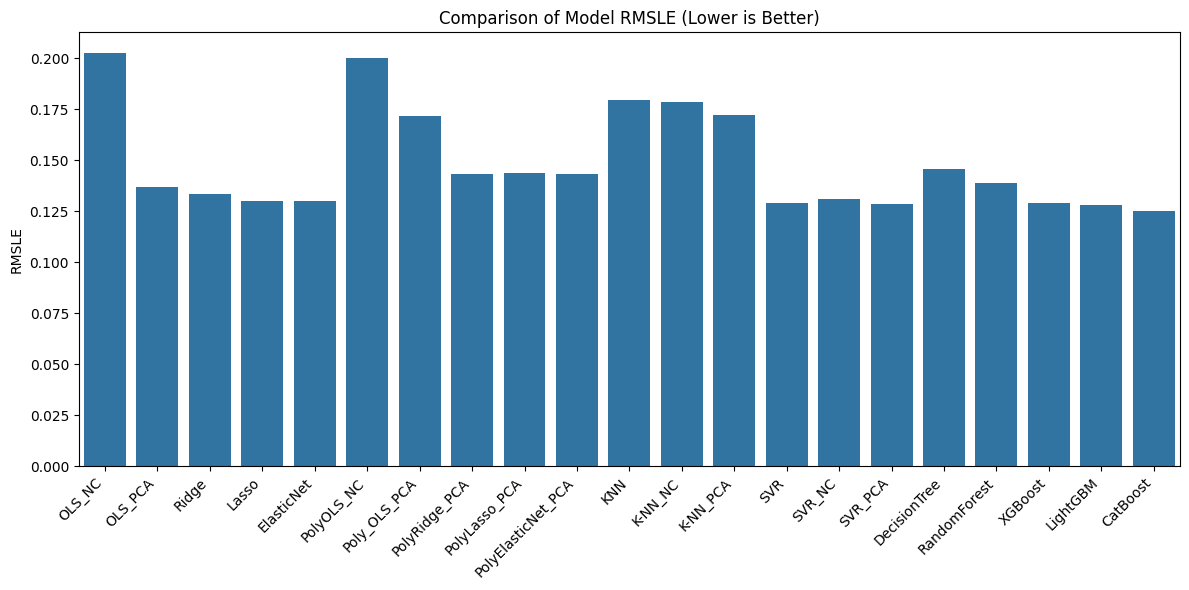

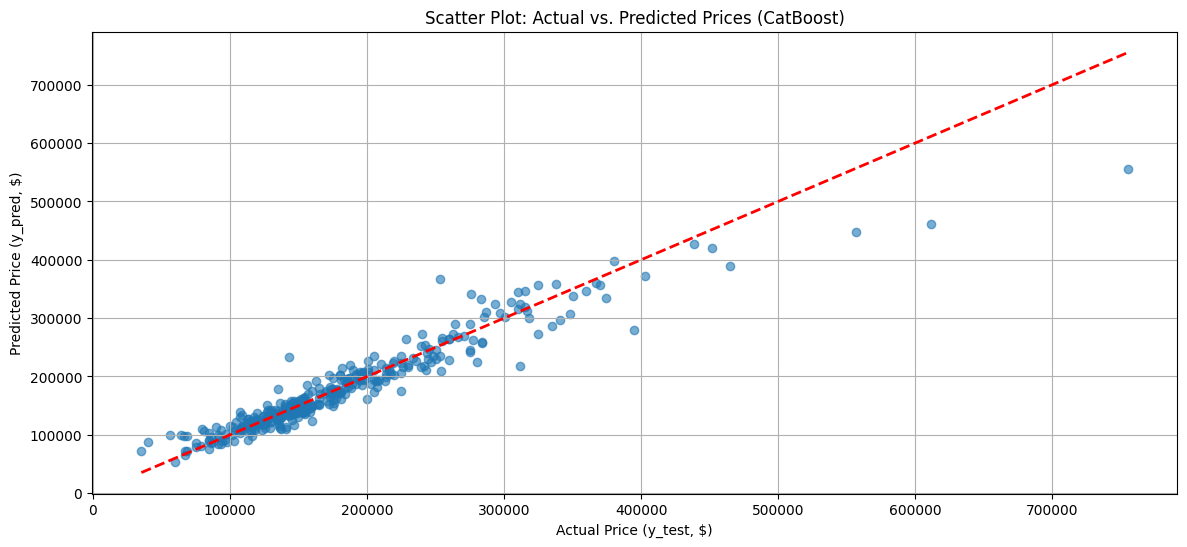

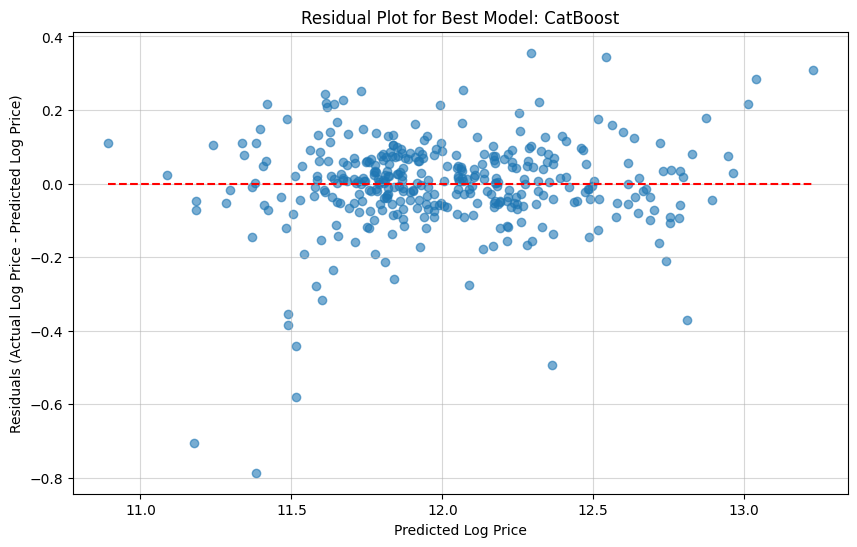

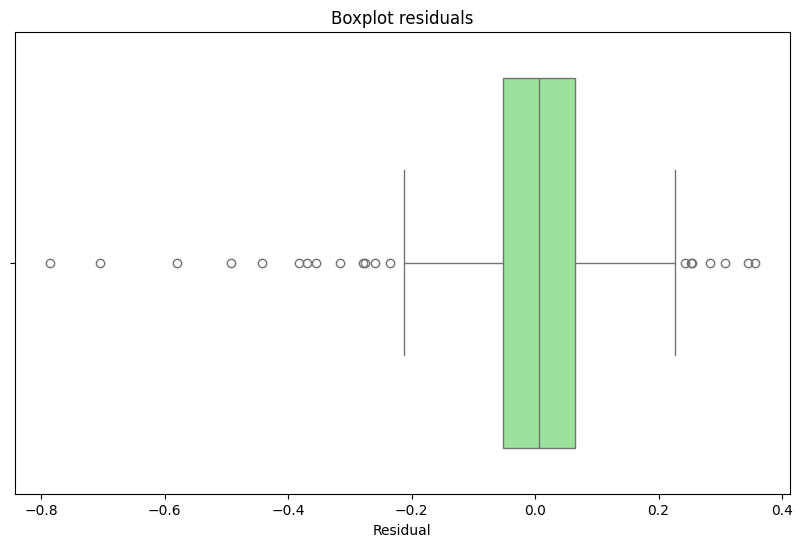

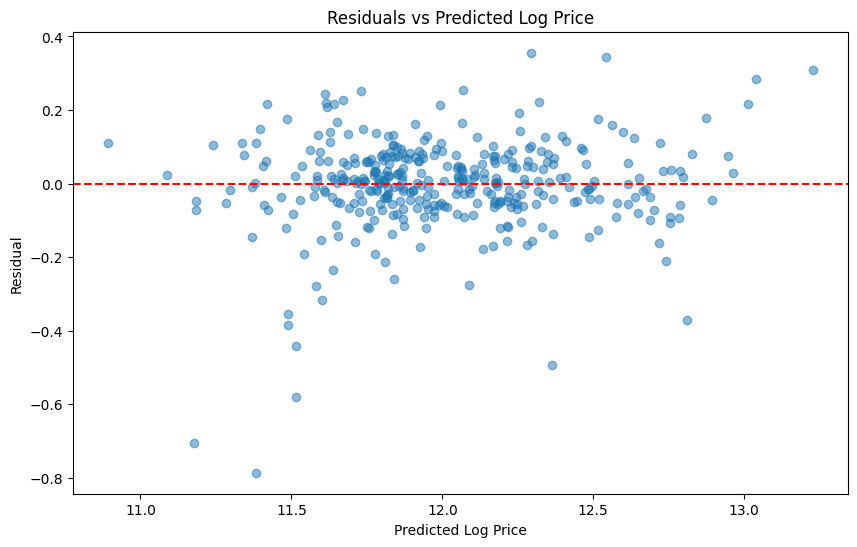


Best Model: **CatBoost** with RMSLE = **0.12527**


In [249]:
metrics_df = pd.DataFrame({
    name: {key: val for key, val in res.items() if key !=  'y_pred'} 
    for name, res in results.items()}).T

print("\nSummary Metrics Table\n")
metrics_df_display = metrics_df.copy()
metrics_df_display['RMSE ($)'] = metrics_df_display['RMSE ($)'].round(0).astype(int)
metrics_df_display['MAE ($)'] = metrics_df_display['MAE ($)'].round(0).astype(int)
print(metrics_df_display.sort_values(by = 'RMSLE', ascending = True))

plt.figure(figsize = (12, 6))
sns.barplot(x = metrics_df.index, y = metrics_df['RMSLE'])
plt.title('Comparison of Model RMSLE (Lower is Better)')
plt.xlabel('')
plt.ylabel('RMSLE')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.savefig('images/rmsle_comparison.png')
plt.show()

best_model_name = metrics_df['RMSLE'].idxmin()

plt.figure(figsize = (14, 6))
plt.scatter(y_test, results[best_model_name]['y_pred'], alpha = 0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw = 2)
plt.xlabel('Actual Price (y_test, $)')
plt.ylabel('Predicted Price (y_pred, $)')
plt.title(f'Scatter Plot: Actual vs. Predicted Prices ({best_model_name})')
plt.grid(True)
plt.savefig('images/actual_vs_predicted.png')
plt.show()

y_pred_log_best = np.log1p(results[best_model_name]['y_pred'])
residuals = y_test_log - y_pred_log_best

plt.figure(figsize = (10, 6))
plt.scatter(y_pred_log_best, residuals, alpha = 0.6)
plt.hlines(y = 0, xmin = y_pred_log_best.min(), xmax = y_pred_log_best.max(), color = 'red', linestyle = '--')
plt.xlabel('Predicted Log Price')
plt.ylabel('Residuals (Actual Log Price - Predicted Log Price)')
plt.title(f'Residual Plot for Best Model: {best_model_name}')
plt.grid(True, alpha = 0.5)
plt.savefig('images/residual_plot_1.png')
plt.show()

plt.figure(figsize = (10, 6))
sns.boxplot(x = residuals, color = 'lightgreen')
plt.title('Boxplot residuals')
plt.xlabel('Residual')
plt.savefig('images/residual_plot_2.png')
plt.show()

plt.figure(figsize = (10, 6))
plt.scatter(y_pred_log_best, residuals, alpha = 0.5)
plt.axhline(0, color = 'red', linestyle = '--')
plt.xlabel('Predicted Log Price')
plt.ylabel('Residual')
plt.title('Residuals vs Predicted Log Price')
plt.savefig('images/residual_plot_3.png')
plt.show()

print(f"\nBest Model: **{best_model_name}** with RMSLE = **{metrics_df.loc[best_model_name, 'RMSLE']:.5f}**")

## The importance of features

Using best model: CatBoost


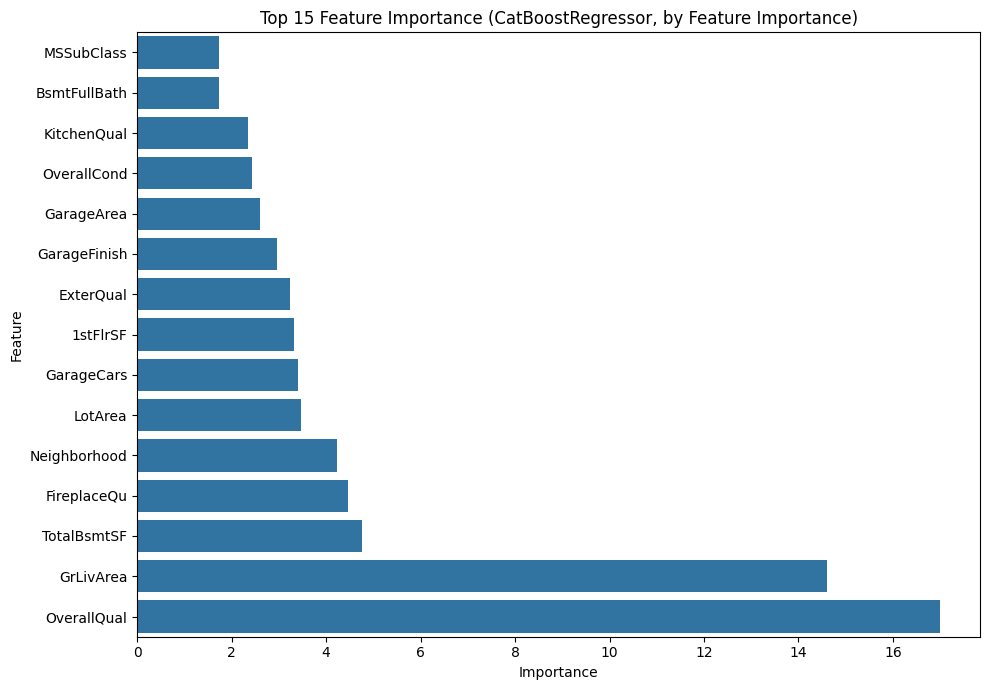

In [241]:
X_data_for_pfi = X_train_test
y_data_for_pfi = y_test_log

best_model = final_pipelines[best_model_name]
print(f"Using best model: {best_model_name}")

if hasattr(best_model, 'named_steps'):
    regressor = best_model.named_steps['regressor']
    poly_transformer = best_model.named_steps.get('poly') 
    preprocessor = best_model.named_steps['preprocessor']
else:
    regressor = best_model
    poly_transformer = None
    preprocessor = None

model_name = regressor.__class__.__name__

if hasattr(regressor, 'feature_importances_'):
    importances = regressor.feature_importances_
    method = "Feature Importance"
elif hasattr(regressor, 'coef_'):
    importances = np.abs(regressor.coef_)
    method = "Absolute Coefficients"
else:
    print(f"\nModel {model_name} does not support standard attributes. Calculating Permutation Importance (PFI)...")
    start_time = time.time()

    r = permutation_importance(
        best_model,                 
        X_data_for_pfi, 
        y_data_for_pfi, 
        scoring='neg_mean_squared_error', 
        n_repeats=10, 
        random_state=42, 
        n_jobs=-1)
    
    importances = r.importances_mean
    method = "Permutation Importance"
    print(f"PFI calculated in {time.time() - start_time:.2f} seconds.")

if poly_transformer is not None:
    try:
        preprocessor_output_features = preprocessor.get_feature_names_out(input_features = X_train_train.columns)
    except:
        try:
             preprocessor_output_features = preprocessor.get_feature_names_out()
        except:
             preprocessor_output_features = [f'P_Feat_{i}' for i in range(len(importances))]
             print("WARNING: Could not retrieve names from preprocessor. Using placeholders.")
            
    expanded_feature_names = poly_transformer.get_feature_names_out(input_features = preprocessor_output_features)
    feature_names_final = expanded_feature_names
    title_suffix = f' ({model_name} with Poly, by {method})'
else:
    if preprocessor is not None:
        try:
            feature_names_final = preprocessor.get_feature_names_out(input_features = X_train_train.columns)
        except:
            feature_names_final = X_data_for_pfi.columns 
    else:
        feature_names_final = X_data_for_pfi.columns 
    title_suffix = f' ({model_name}, by {method})'

if len(feature_names_final) != len(importances):
    print(f"Feature count mismatch: Names ({len(feature_names_final)}) != Importances ({len(importances)}).")
    feature_names_final = [f'Feat_{i}' for i in range(len(importances))]
    print("!!! Using generic feature names as fallback.")
    
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_final,
    'Importance': importances})

feature_importance_df = feature_importance_df[feature_importance_df['Importance'] > 0] 

top_15_features = feature_importance_df.sort_values(by = 'Importance', ascending = False).head(15)

plt.figure(figsize = (10, 7))
sns.barplot(x = 'Importance', y = 'Feature', data = top_15_features.sort_values(by = 'Importance', ascending = True)) 
plt.title(f'Top 15 Feature Importance' + title_suffix)
plt.tight_layout()
plt.savefig('images/feature_importance.png')

## Final prediction and submission file generation

In [242]:
y_pred_log = best_model.predict(X_test) 

y_pred_original = np.expm1(y_pred_log) 
y_pred_original[y_pred_original < 0] = 0 

submission_df = pd.DataFrame({
    'Id': X.iloc[N_rows_x_train:, :]['Id'],
    'SalePrice': y_pred_original})

print("\nFirst 5 Predictions:")
print(submission_df.head())

submission_file_name = f'submission_{best_model_name}.csv'
submission_df.to_csv(submission_file_name, index = False)


First 5 Predictions:
        Id      SalePrice
1460  1461  120654.378332
1461  1462  154489.238929
1462  1463  187444.656791
1463  1464  188360.697724
1464  1465  190956.607486
